In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, f1_score, precision_score, 
                            recall_score)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/train_processed.csv')
test_df = pd.read_csv('C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/test_processed.csv')
X_train = train_df['tweet_cleaned']
y_train = train_df['class']
X_test = test_df['tweet_cleaned']
y_test = test_df['class']

print("="*70)
print("DATA LOADED")
print("="*70)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

DATA LOADED
Training samples: 19,824
Testing samples: 4,956

Class distribution in training set:
class
0     1144
1    15351
2     3329
Name: count, dtype: int64


In [3]:
print("\n" + "="*70)
print("FEATURE EXTRACTION: TF-IDF")
print("="*70)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF vectorization complete")
print(f"Training shape: {X_train_tfidf.shape}")
print(f"Testing shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")
joblib.dump(tfidf_vectorizer, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/tfidf_vectorizer.pkl')
print(f"\nVectorizer saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/tfidf_vectorizer.pkl")


FEATURE EXTRACTION: TF-IDF
TF-IDF vectorization complete
Training shape: (19824, 5000)
Testing shape: (4956, 5000)
Vocabulary size: 5,000

Sample features: ['able', 'abo', 'absolute', 'absolutely', 'abt', 'accent', 'accept', 'accident', 'account', 'across', 'act', 'act like', 'actin', 'actin like', 'acting', 'acting like', 'action', 'actor', 'actual', 'actually']

Vectorizer saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/tfidf_vectorizer.pkl


In [4]:
print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1_macro = f1_score(y_test, y_pred_lr, average='macro')
lr_f1_weighted = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\nTraining complete!")
print(f"\nPerformance Metrics:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-Score (Macro): {lr_f1_macro:.4f}")
print(f"F1-Score (Weighted): {lr_f1_weighted:.4f}")

joblib.dump(lr_model, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/logistic_regression.pkl')
print(f"\nModel saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/logistic_regression.pkl")


MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression...

Training complete!

Performance Metrics:
Accuracy: 0.8515
F1-Score (Macro): 0.7202
F1-Score (Weighted): 0.8676

Model saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/logistic_regression.pkl


In [5]:
print("\n" + "="*70)
print("MODEL 2: LINEAR SUPPORT VECTOR MACHINE")
print("="*70)
svm_model = LinearSVC(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)
print("Training Linear SVM...")
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1_macro = f1_score(y_test, y_pred_svm, average='macro')
svm_f1_weighted = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\nTraining complete!")
print(f"\nPerformance Metrics:")
print(f"  Accuracy: {svm_accuracy:.4f}")
print(f"  F1-Score (Macro): {svm_f1_macro:.4f}")
print(f"  F1-Score (Weighted): {svm_f1_weighted:.4f}")

joblib.dump(svm_model, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/svm_model.pkl')
print(f"\nModel saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/svm_model.pkl")


MODEL 2: LINEAR SUPPORT VECTOR MACHINE
Training Linear SVM...

Training complete!

Performance Metrics:
  Accuracy: 0.8803
  F1-Score (Macro): 0.7151
  F1-Score (Weighted): 0.8830

Model saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/svm_model.pkl


In [6]:
print("\n" + "="*70)
print("MODEL 3: MULTINOMIAL NAIVE BAYES")
print("="*70)

nb_model = MultinomialNB(alpha=1.0)
print("Training Naive Bayes...")
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1_macro = f1_score(y_test, y_pred_nb, average='macro')
nb_f1_weighted = f1_score(y_test, y_pred_nb, average='weighted')
print(f"\nTraining complete!")
print(f"\nPerformance Metrics:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"F1-Score (Macro): {nb_f1_macro:.4f}")
print(f"F1-Score (Weighted): {nb_f1_weighted:.4f}")

joblib.dump(nb_model, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/naive_bayes.pkl')
print(f"\nModel saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/naive_bayes.pkl")


MODEL 3: MULTINOMIAL NAIVE BAYES
Training Naive Bayes...

Training complete!

Performance Metrics:
Accuracy: 0.8475
F1-Score (Macro): 0.5179
F1-Score (Weighted): 0.8109

Model saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/naive_bayes.pkl


In [7]:
print("\n" + "="*70)
print("MODEL 4: RANDOM FOREST")
print("="*70)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
print("Training Random Forest... (This may take a few minutes)")
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')
rf_f1_weighted = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nTraining complete!")
print(f"\nPerformance Metrics:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-Score (Macro): {rf_f1_macro:.4f}")
print(f"F1-Score (Weighted): {rf_f1_weighted:.4f}")

joblib.dump(rf_model, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/random_forest.pkl')
print(f"\nModel saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/random_forest.pkl")


MODEL 4: RANDOM FOREST
Training Random Forest... (This may take a few minutes)

Training complete!

Performance Metrics:
Accuracy: 0.8789
F1-Score (Macro): 0.7344
F1-Score (Weighted): 0.8823

Model saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/random_forest.pkl


In [8]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [lr_accuracy, svm_accuracy, nb_accuracy, rf_accuracy],
    'F1-Score (Macro)': [lr_f1_macro, svm_f1_macro, nb_f1_macro, rf_f1_macro],
    'F1-Score (Weighted)': [lr_f1_weighted, svm_f1_weighted, nb_f1_weighted, rf_f1_weighted]
})
print(f"\n{results.to_string(index=False)}")

best_model_idx = results['F1-Score (Weighted)'].idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
best_f1 = results.loc[best_model_idx, 'F1-Score (Weighted)']
print(f"\nBEST MODEL: {best_model_name}")
print(f"F1-Score (Weighted): {best_f1:.4f}")


MODEL COMPARISON

              Model  Accuracy  F1-Score (Macro)  F1-Score (Weighted)
Logistic Regression  0.851493          0.720177             0.867631
         Linear SVM  0.880347          0.715101             0.882980
        Naive Bayes  0.847458          0.517867             0.810932
      Random Forest  0.878935          0.734386             0.882344

BEST MODEL: Linear SVM
F1-Score (Weighted): 0.8830


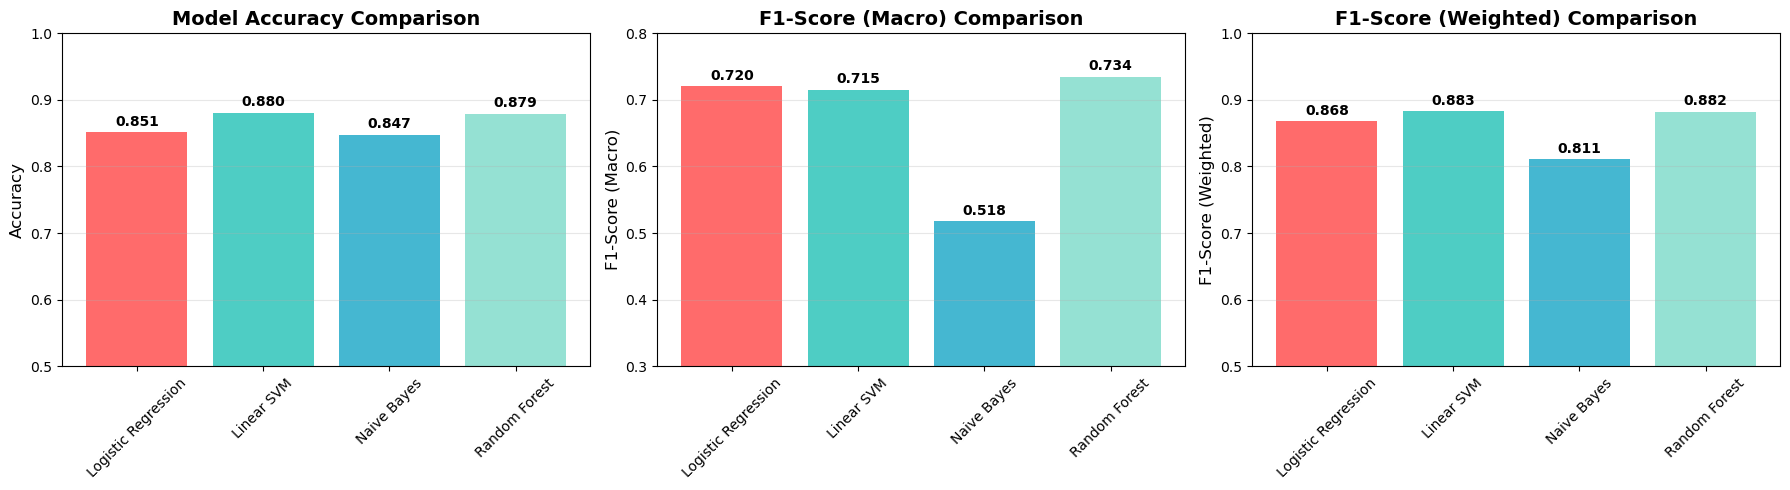


Comparison visualization saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results['Model'], results['Accuracy'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim([0.5, 1.0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(results['Model'], results['F1-Score (Macro)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'])
axes[1].set_title('F1-Score (Macro) Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)', fontsize=12)
axes[1].set_ylim([0.3, 0.8])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(results['F1-Score (Macro)']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(results['Model'], results['F1-Score (Weighted)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'])
axes[2].set_title('F1-Score (Weighted) Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('F1-Score (Weighted)', fontsize=12)
axes[2].set_ylim([0.5, 1.0])
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

for i, v in enumerate(results['F1-Score (Weighted)']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nComparison visualization saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/model_comparison.png")

In [13]:
model_dict = {
    'Logistic Regression': lr_model,
    'Linear SVM': svm_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model
}
best_model = model_dict[best_model_name]
joblib.dump(best_model, 'C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/best_model.pkl')

print("\n" + "="*70)
print("BEST MODEL SAVED")
print("="*70)
print(f"Best model ({best_model_name}) saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/best_model.pkl")

metadata = {
    'best_model_name': best_model_name,
    'accuracy': best_f1,
    'all_results': results.to_dict()
}

import json
with open('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/model_metadata.json")

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE!")
print("="*70)
print(f"\nAll models trained and saved:")
print(f"-> Logistic Regression")
print(f"-> Linear SVM")
print(f"-> Naive Bayes")
print(f"-> Random Forest")
print(f"\nBest performing model: {best_model_name}")


BEST MODEL SAVED
Best model (Linear SVM) saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/best_model.pkl
Metadata saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/model_metadata.json

MODEL TRAINING COMPLETE!

All models trained and saved:
-> Logistic Regression
-> Linear SVM
-> Naive Bayes
-> Random Forest

Best performing model: Linear SVM
